In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
import seaborn as sns

project_root = Path().resolve().parent
data_dir = project_root / "data"

required_files = [
    "orders.csv",
    "products.csv",
    "aisles.csv",
    "departments.csv",
    "order_products__prior.csv",
]

orders = pd.read_csv(data_dir / "orders.csv")
products = pd.read_csv(data_dir / "products.csv")
aisles = pd.read_csv(data_dir / "aisles.csv")
departments = pd.read_csv(data_dir / "departments.csv")
order_products = pd.read_csv(data_dir / "order_products__prior.csv")

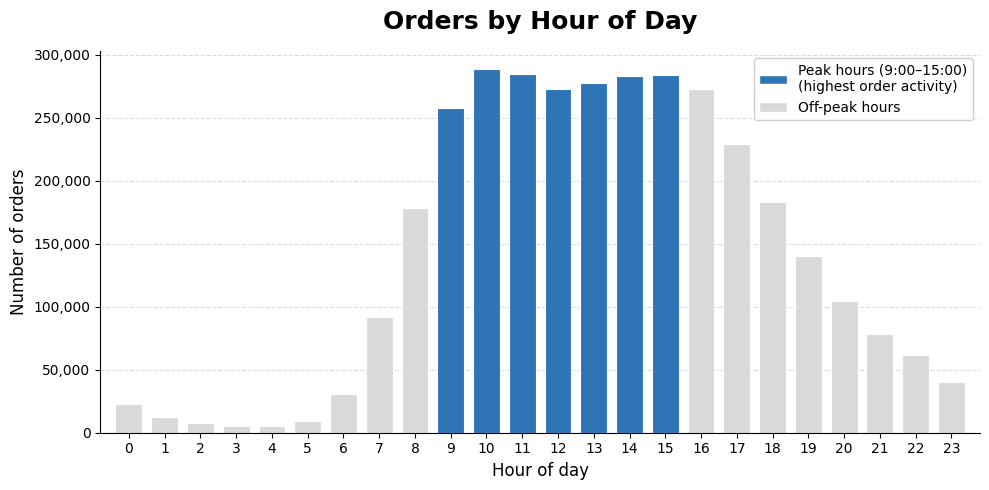

In [3]:
orders_by_hour = orders.groupby("order_hour_of_day")["order_id"].count()

fig, ax = plt.subplots(figsize=(10, 5))

peak_color = "#2F75B5"
offpeak_color = "#D9D9D9"

colors = [
    peak_color if 9 <= hour <= 15 else offpeak_color
    for hour in orders_by_hour.index
]

ax.bar(
    orders_by_hour.index,
    orders_by_hour.values,
    color=colors,
    width=0.75,
    edgecolor="white",
    linewidth=0.8
)

ax.set_title("Orders by Hour of Day", fontsize=18, fontweight="bold", pad=16)
ax.set_xlabel("Hour of day", fontsize=12)
ax.set_ylabel("Number of orders", fontsize=12)

ax.set_xticks(range(0, 24, 1))
ax.set_xlim(-0.8, 23.8)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.45)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_elements = [
    Patch(
        facecolor=peak_color,
        edgecolor="white",
        label="Peak hours (9:00–15:00)\n(highest order activity)"
    ),
    Patch(
        facecolor=offpeak_color,
        edgecolor="white",
        label="Off-peak hours"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="#CCCCCC"
)

plt.tight_layout()
plt.show()

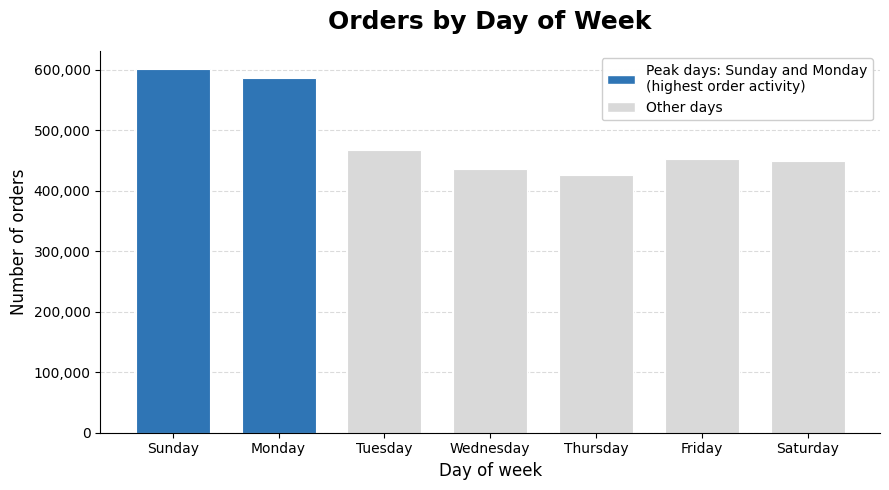

In [4]:
# Prepare data
orders_by_day = orders.groupby("order_dow")["order_id"].count()
orders_by_day.index = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

fig, ax = plt.subplots(figsize=(9, 5))

# Define colors
peak_color = "#2F75B5"
offpeak_color = "#D9D9D9"

colors = [
    peak_color if day in ["Sunday", "Monday"] else offpeak_color
    for day in orders_by_day.index
]

# Plot
ax.bar(
    orders_by_day.index,
    orders_by_day.values,
    color=colors,
    width=0.7,
    edgecolor="white",
    linewidth=0.8
)

# Labels and title
ax.set_title("Orders by Day of Week", fontsize=18, fontweight="bold", pad=16)
ax.set_xlabel("Day of week", fontsize=12)
ax.set_ylabel("Number of orders", fontsize=12)

# Format y-axis with comma separators
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

# Gridlines
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.45)
ax.set_axisbelow(True)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
legend_elements = [
    Patch(
        facecolor=peak_color,
        edgecolor="white",
        label="Peak days: Sunday and Monday\n(highest order activity)"
    ),
    Patch(
        facecolor=offpeak_color,
        edgecolor="white",
        label="Other days"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="#CCCCCC"
)

# Improve x-label readability
plt.xticks()

plt.tight_layout()
plt.show()


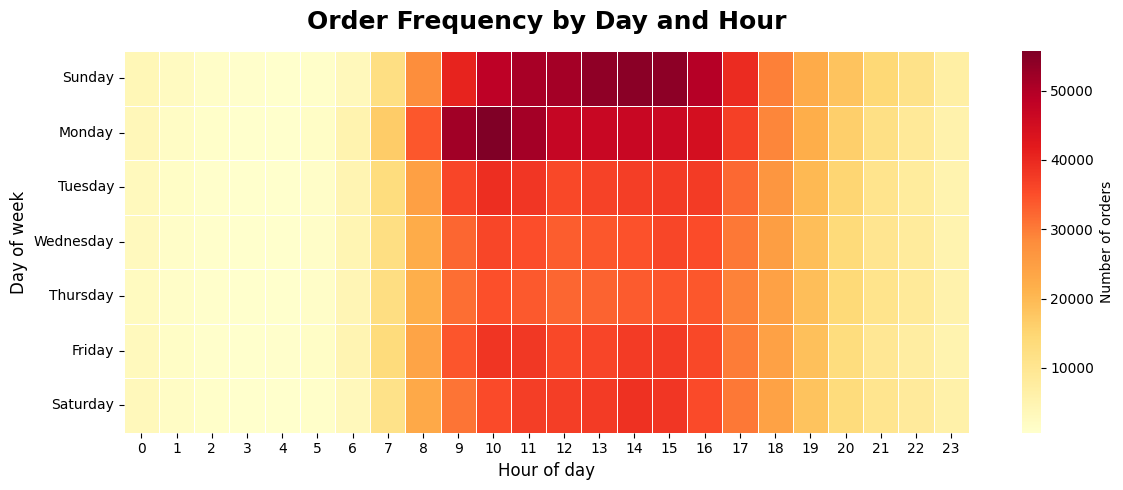

In [5]:

# Prepare data for heatmap
heatmap_data = orders.groupby(
    ["order_dow", "order_hour_of_day"]
)["order_id"].count().unstack()

# Rename days for readability
heatmap_data.index = [
    "Sunday", "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday"
]

fig, ax = plt.subplots(figsize=(12, 5))

# Create heatmap
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of orders"}
)

# Labels and title
ax.set_title("Order Frequency by Day and Hour", fontsize=18, fontweight="bold", pad=16)
ax.set_xlabel("Hour of day", fontsize=12)
ax.set_ylabel("Day of week", fontsize=12)

plt.tight_layout()
plt.show()
